In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
from matplotlib.colors import LinearSegmentedColormap
import warnings 
import os
import random
warnings.filterwarnings("ignore")

device = torch.device("cpu")
rds = np.load('../data/processed_data/rds/lane1/2024-07-09.npy')
speed = np.load('../data/processed_data/rds/lane1/2024-07-09.npy')
motion = np.load('../data/processed_data/motion/lane1/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = '../logs/calibration/20250607_203336/best_model_lane1.pt'

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx

In [7]:
# load the best model
best_model_path = '../model/20250607_221107/best_model_lane1.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
calibrated = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong'],
                          init_c_free=calibrated_model['c_free'],
                          init_v_delta=calibrated_model['v_delta'],
                          init_v_thr=calibrated_model['v_thr']
                          ).to(device)

calibrated.eval()

AdaptiveSmoothing()

In [8]:
original = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=15.00,
                          init_delta=0.15,
                          init_c_cong=9.30,
                          init_c_free=-43.50,
                          init_v_delta=12.40,
                          init_v_thr=37.30).to(device)
original.eval()

AdaptiveSmoothing()

In [9]:
with torch.no_grad():
    smoothed = calibrated(speed)
    calibrated_asm_speed = smoothed.cpu().numpy().squeeze()

In [10]:
with torch.no_grad():
    original_asm = original(speed)
    original_asm_speed = original_asm.cpu().numpy().squeeze()

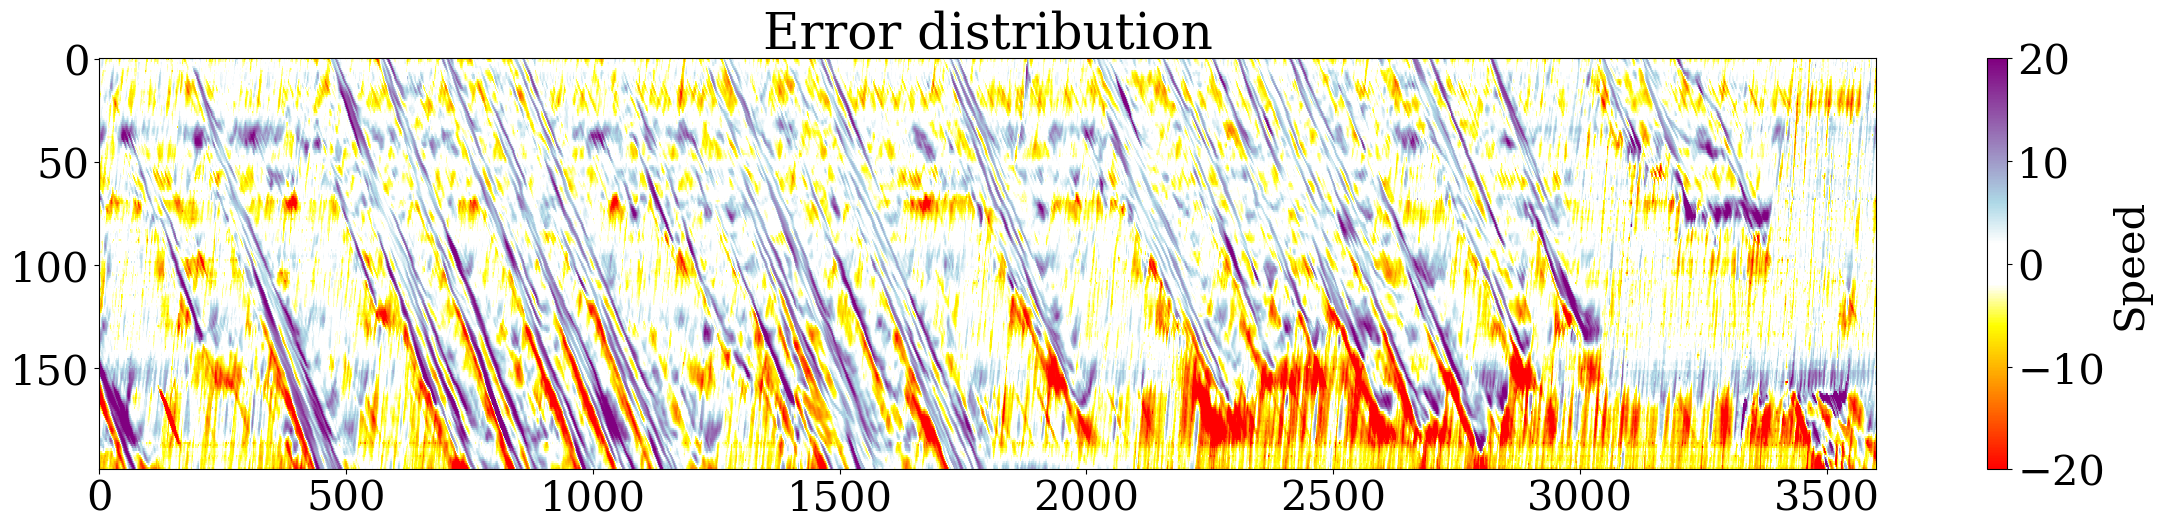

In [11]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
colors = ['red','yellow','white', 'white', 'white','lightblue','purple']
nodes = [0, 0.35,0.45,0.5,0.55,0.65, 1]  # Normalized nodes
cmap = LinearSegmentedColormap.from_list('custom', list(zip(nodes, colors)))
plt.imshow(calibrated_asm_speed - motion, cmap=cmap, interpolation='nearest', origin='lower',vmin=-20, vmax=20, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Error distribution')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure6'):
    os.makedirs('../figures/figure6')
plt.savefig('../figures/figure6/error.pdf', dpi=300, bbox_inches='tight')
plt.show()

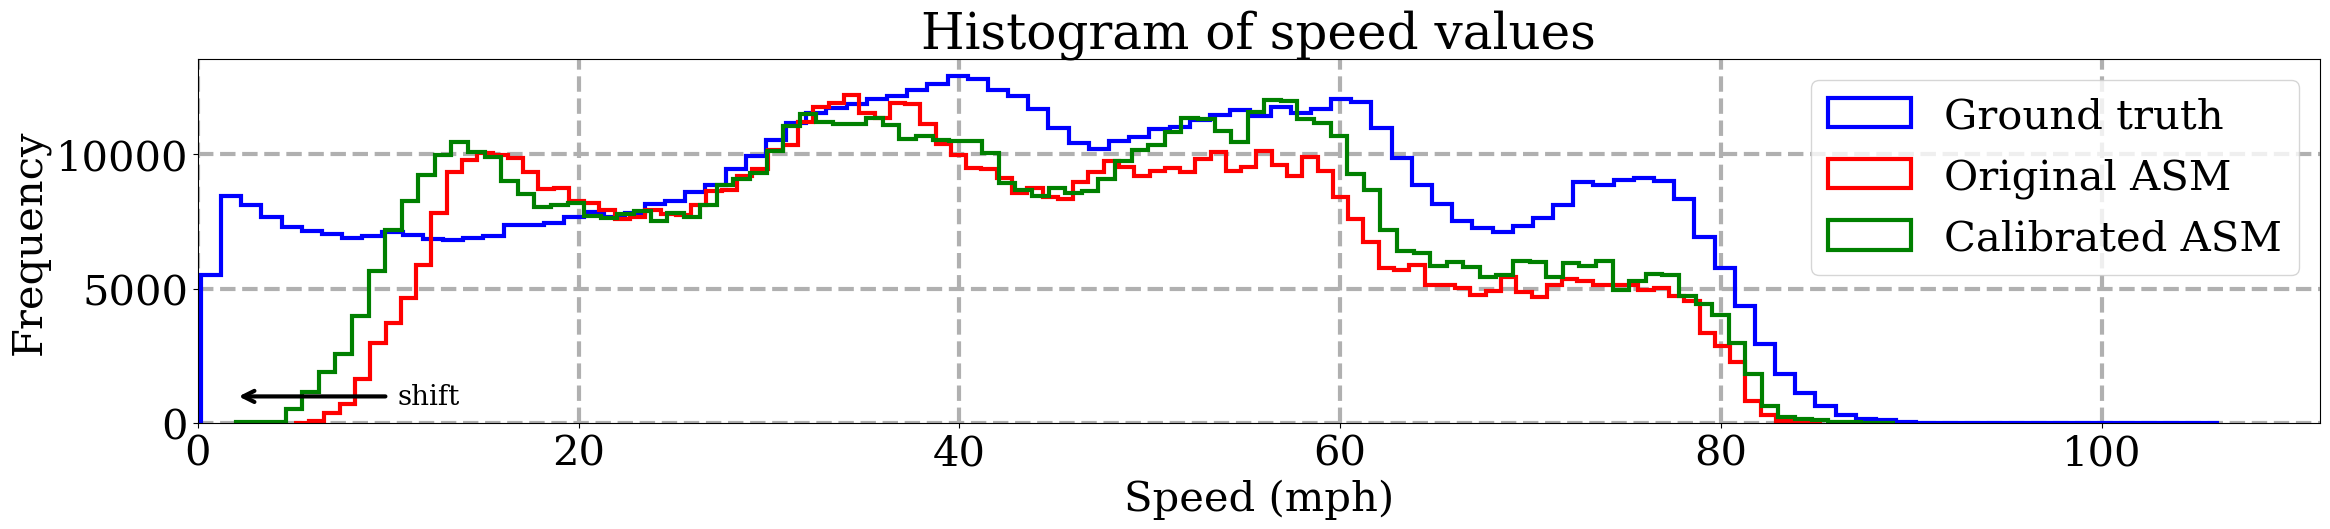

In [17]:
plt.figure(figsize=(24, 6))
plt.hist(motion.flatten(), bins=100, histtype='step', color='blue', label='Ground truth', linewidth=3)
plt.hist(original_asm_speed.flatten(), bins=100, histtype='step', color='red', label='Original ASM', linewidth=3)
plt.hist(calibrated_asm_speed.flatten(), bins=100, histtype='step', color='green', label='Calibrated ASM', linewidth=3)
plt.xlabel('Speed (mph)')
plt.ylabel('Frequency')
plt.title('Histogram of speed values')
plt.legend()
plt.tight_layout()
plt.xlim(0, )
plt.grid(lw=3, ls='--')
# add an arrow at (10, 1000) pointing to the right
plt.annotate('', xy=(2, 1000), xytext=(10, 1000),
             arrowprops=dict(arrowstyle='->', lw=3, color='black'),
             fontsize=20, ha='center', va='center')
# add text at the arrow
plt.text(10.5, 1000, 'shift', fontsize=20, ha='left', va='center', color='black')
if not os.path.exists('../figures/figure6'):
    os.makedirs('../figures/figure6')
plt.savefig('../figures/figure6/histogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

RDS Index: [  5   5   5 ... 196 196 196]


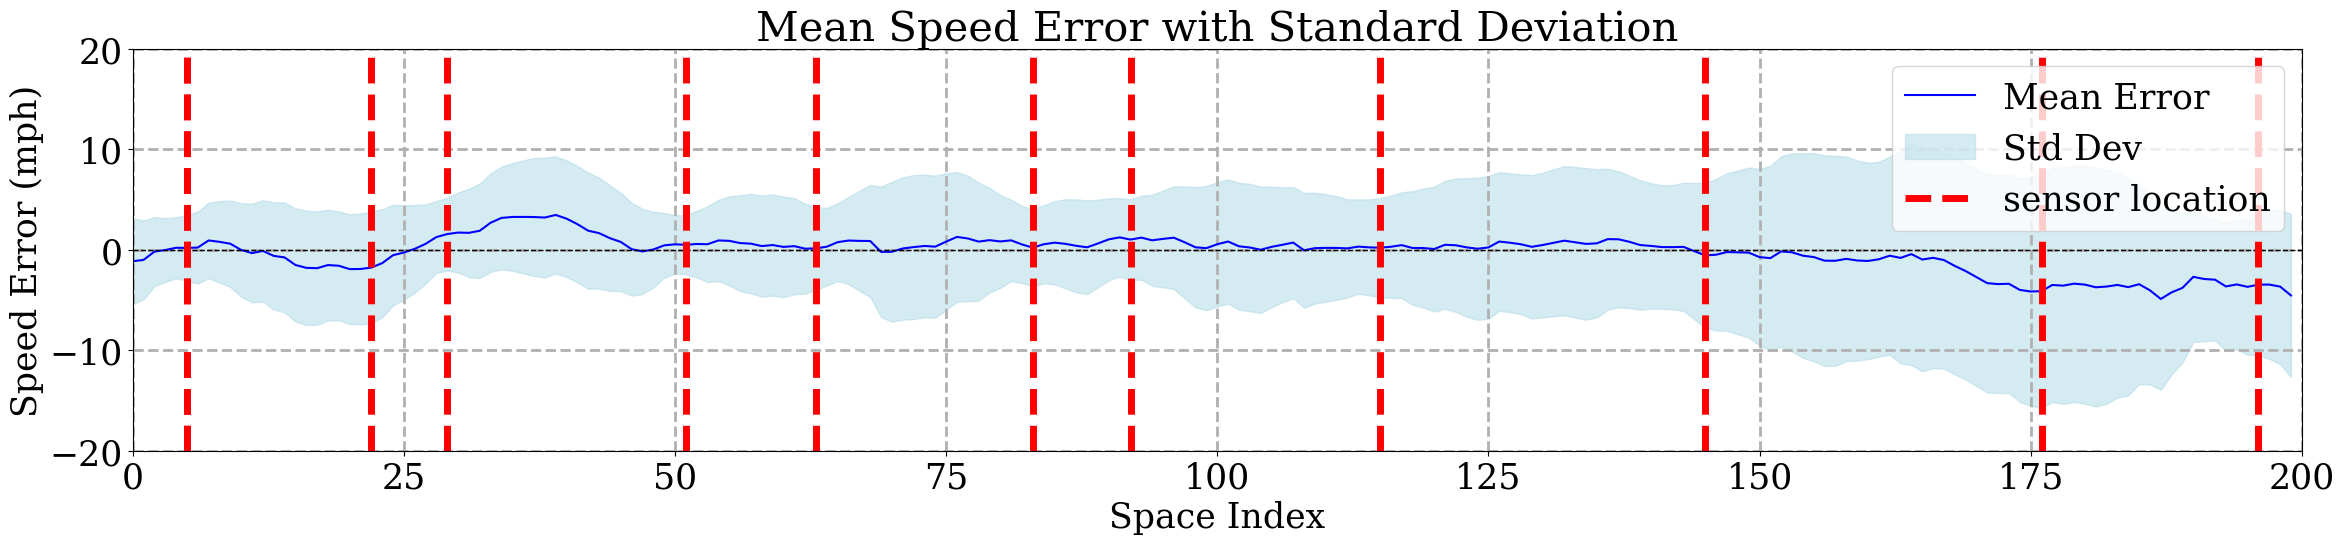

In [ ]:
# show the error distribution along th y-axis
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 25, 'font.family': 'serif'})
error = calibrated_asm_speed - motion
# get the index of rds not all the element are nan
rds_index = np.where(~np.isnan(rds))[0]
print(f"RDS Index: {rds_index}")
# get the unique index
unique_rds_index = np.unique(rds_index)
plt.plot(np.mean(error, axis=1), label='Mean Error', color='blue')
plt.fill_between(
    range(error.shape[0]),
    np.mean(error, axis=1) - np.std(error, axis=1),
    np.mean(error, axis=1) + np.std(error, axis=1),
    color='lightblue', alpha=0.5, label='Std Dev'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Space Index')
plt.ylabel('Speed Error (mph)')
plt.title('Mean Speed Error with Standard Deviation')
# draw vertical lines at the rds index
for idx in unique_rds_index:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=5, label = 'sensor location')
    break
for idx in unique_rds_index:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=5)
plt.legend(fontsize=25)
plt.xlim(0, error.shape[0])
plt.ylim(-20, 20)
plt.grid(lw=2, ls='--')
plt.tight_layout()
if not os.path.exists('../figures/figure6'):
    os.makedirs('../figures/figure6')
plt.savefig('../figures/figure6/mean_error_location.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

print(f"Unique RDS Index: {unique_rds_index}")

RDS Index: [  5   5   5 ... 196 196 196]
Unique RDS Index: [  5  22  29  51  63  83  92 115 145 176 196]


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
from matplotlib.colors import LinearSegmentedColormap
import warnings 
import os
import random
warnings.filterwarnings("ignore")

device = torch.device("cpu")
rds = np.load('../data/processed_data/rds/lane4/2024-07-09.npy')
speed = np.load('../data/processed_data/rds/lane4/2024-07-09.npy')
motion = np.load('../data/processed_data/motion/lane4/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = '../logs/calibration/20250607_203336/best_model_lane4.pt'

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx
# load the best model
best_model_path = '../model/20250607_221107/best_model_lane1.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
calibrated = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong'],
                          init_c_free=calibrated_model['c_free'],
                          init_v_delta=calibrated_model['v_delta'],
                          init_v_thr=calibrated_model['v_thr']
                          ).to(device)

calibrated.eval()
original = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=15.00,
                          init_delta=0.15,
                          init_c_cong=9.30,
                          init_c_free=-43.50,
                          init_v_delta=12.40,
                          init_v_thr=37.30).to(device)
original.eval()
with torch.no_grad():
    smoothed = calibrated(speed)
    calibrated_asm_speed = smoothed.cpu().numpy().squeeze()

RDS Index: [  5   5   5 ... 196 196 196]


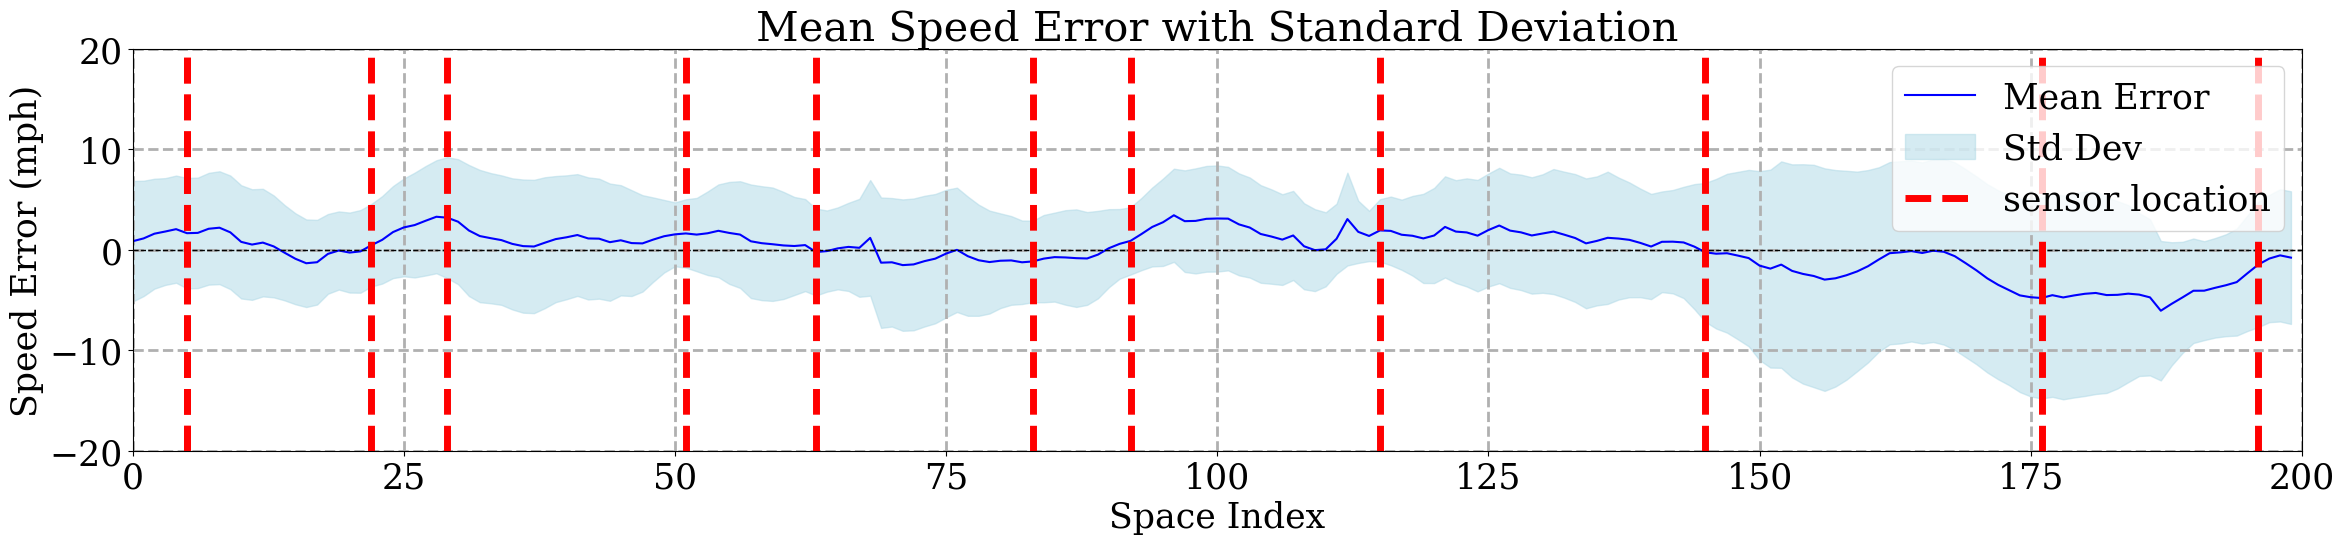

In [4]:
# show the error distribution along th y-axis
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 25, 'font.family': 'serif'})
error = calibrated_asm_speed - motion
# get the index of rds not all the element are nan
rds_index = np.where(~np.isnan(rds))[0]
print(f"RDS Index: {rds_index}")
# get the unique index
unique_rds_index = np.unique(rds_index)
plt.plot(np.mean(error, axis=1), label='Mean Error', color='blue')
plt.fill_between(
    range(error.shape[0]),
    np.mean(error, axis=1) - np.std(error, axis=1),
    np.mean(error, axis=1) + np.std(error, axis=1),
    color='lightblue', alpha=0.5, label='Std Dev'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Space Index')
plt.ylabel('Speed Error (mph)')
plt.title('Mean Speed Error with Standard Deviation')
# draw vertical lines at the rds index
for idx in unique_rds_index:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=5, label = 'sensor location')
    break
for idx in unique_rds_index:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=5)
plt.legend(fontsize=25)
plt.xlim(0, error.shape[0])
plt.ylim(-20, 20)
plt.grid(lw=2, ls='--')
plt.tight_layout()
if not os.path.exists('../figures/figure6'):
    os.makedirs('../figures/figure6')
plt.savefig('../figures/figure6/lane4_mean_error_location.pdf', dpi=300, bbox_inches='tight')
plt.show()